In [1]:
# This is our very first cell in the Jupyter Notebook.
# We can run this cell to make sure the Python kernel is working.
print("Hello, Jupyter! The analysis can now begin.")

Hello, Jupyter! The analysis can now begin.


In [2]:
# First, we import the pandas library, which is the industry standard for data manipulation in Python.
# We give it the conventional alias 'pd' to make our code cleaner and easier to type.
import pandas as pd

# Next, we define the file path to our dataset.
# This is a crucial step. We use a relative path. The '../' tells the notebook to go
file_path = '../data/IMDB Dataset.csv'

# Now, we use the powerful 'read_csv' function from pandas to load the data.
# This function reads the CSV file, parses its contents, and creates a DataFrame object.
df = pd.read_csv(file_path)

# As a good practice, we'll print a confirmation message. This tells us the code
# in the cell ran without errors and the 'df' variable now holds our data.
print("Dataset loaded successfully into a Pandas DataFrame!")

Dataset loaded successfully into a Pandas DataFrame!


In [3]:
# The .head() method is called directly on our DataFrame 'df'.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# The .shape attribute is accessed directly on the DataFrame 'df' without parentheses.
# It returns a Python tuple of the form (rows, columns).
df.shape

(50000, 2)

In [5]:
# To check for missing values, we chain two methods together.
# 1. df.isnull(): This method scans the entire DataFrame and returns a
#    DataFrame of the same size, but with boolean values. It places 'True'
#    wherever a value is missing (null/NaN) and 'False' otherwise.
#
# 2. .sum(): When we call .sum() on this boolean DataFrame, Pandas treats
#    True as 1 and False as 0. This effectively counts the number of 'True'
#    values in each column, giving us a total count of missing data per column.
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
# The .value_counts() method is called on a single column (a Pandas Series).\n# We select the 'sentiment' column from our DataFrame 'df' using bracket notation: df['sentiment'].
# This method then iterates through all 50,000 entries in that column,
# counts the occurrences of each unique value ('positive' and 'negative'),
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

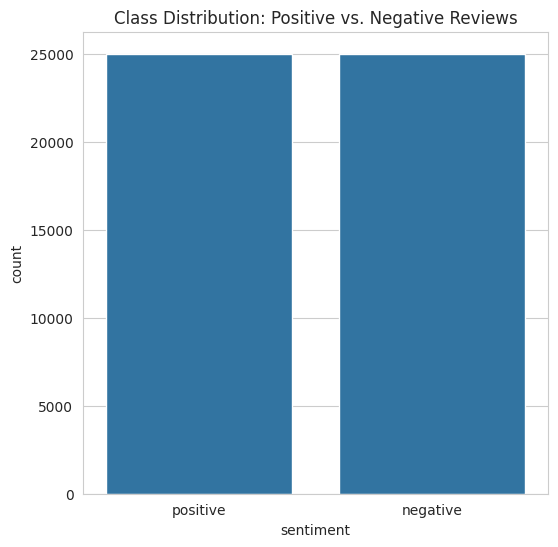

In [7]:
# Import the visualization libraries we installed earlier.
# 'matplotlib.pyplot' is the foundational plotting library, often aliased as 'plt'.
# 'seaborn' is built on top of matplotlib and makes creating beautiful statistical plots easier, aliased as 'sns'.
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_style('whitegrid')

# Create the count plot.
# sns.countplot() is specifically designed to show the counts of observations in each categorical bin.
# We tell it to use the 'sentiment' column from our DataFrame 'df' for the x-axis.
plt.figure(figsize=(6,6)) # Optional: Adjusts the figure size for better readability
sns.countplot(x='sentiment', data=df)

# Add a title to the plot for clarity.
plt.title('Class Distribution: Positive vs. Negative Reviews')

# Display the plot.
plt.show()

In [8]:
# We define a function to encapsulate the lowercasing logic.
# This makes our code modular, reusable, and easy to test.
# The function accepts one argument, `text`, which is expected to be a string.
def to_lowercase(text):
    """
    Converts a given text string to lowercase.
    
    Args:
        text (str): The input string to be converted.
        
    Returns:
        str: The lowercased version of the input string.
    """
    return text.lower()

# Let's test our function with an example sentence to verify it works as expected.
# This is a crucial step to ensure our logic is correct before applying it to the entire dataset.
example_text = "This is a GREAT Movie! I REALLY enjoyed it."
cleaned_text = to_lowercase(example_text)

print("Original Text:  ", example_text)
print("Lowercased Text:", cleaned_text)

Original Text:   This is a GREAT Movie! I REALLY enjoyed it.
Lowercased Text: this is a great movie! i really enjoyed it.


In [9]:
# We are now applying the 'to_lowercase' function we created in the previous step.
# We select the 'review' column (which is a Pandas Series) from our DataFrame 'df'.
# Then, we call the .apply() method on this Series.
# We pass our function, 'to_lowercase', as the argument.
# IMPORTANT: We pass the function object itself, not the result of calling it (i.e., no parentheses).
# Pandas will then iterate through each review in the Series and apply this function to it.
# The result is a new Series containing all the lowercased reviews.
df['review'] = df['review'].apply(to_lowercase)

# To verify that our operation was successful, let's inspect the first few rows again.
# This is a critical step in any data transformation pipeline: always check your work!
print("DataFrame after applying the lowercase function:")
df.head()

DataFrame after applying the lowercase function:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [10]:
# We need to import Python's built-in 're' module to work with regular expressions.
import re

# We define a function to encapsulate the HTML tag removal logic.
# This keeps our code organized and makes it easy to reuse and test.
def remove_html_tags(text):
    """
    Removes HTML tags from a text string using a regular expression.
    
    Args:
        text (str): The input string that may contain HTML tags.
        
    Returns:
        str: The text with all HTML tags removed.
    """
    # We define our regular expression pattern. The 're.compile()' function compiles the
    # pattern into a pattern object, which can be more efficient if you're using it many times.
    pattern = re.compile('<.*?>')
    
    # The 're.sub(pattern, replacement, string)' function finds all substrings
    # where the pattern matches and replaces them with the 'replacement' string.
    # Here, we replace every matched HTML tag with an empty string (''), which deletes it.
    return pattern.sub('', text)

# It's crucial to test our function with a sample case before applying it to 50,000 reviews.
# This example includes the '<br />' tag we've seen, plus a bold tag '<b>'.
example_text_with_html = "this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching."
cleaned_text = remove_html_tags(example_text_with_html)

print("Original Text with HTML:  ", example_text_with_html)
print("Text after HTML removal:", cleaned_text)

Original Text with HTML:   this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching.
Text after HTML removal: this was an amazing movie. i loved it! totally worth watching.


In [11]:
# We are now applying the 'remove_html_tags' function we created and tested in the last step.
# We select the 'review' column and call the .apply() method on it, passing our function
# as the argument. Remember to pass the function object itself (remove_html_tags)
# without the parentheses.
df['review'] = df['review'].apply(remove_html_tags)

# The 'golden rule' of data transformation is to always verify your results.
# We'll use .head() again to inspect the first few rows and confirm that the
# HTML tags, like '<br />', are gone.
print("DataFrame after removing HTML tags:")
df.head()

DataFrame after removing HTML tags:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [12]:
# The 're' module is already imported, but it's good practice to ensure it's here.
import re

# We define a function to encapsulate the punctuation removal logic.
def remove_punctuation(text):
    """
    Removes punctuation and special characters from a text string.
    
    This function uses a regular expression to find and remove any character that is
    not a lowercase letter (a-z), a digit (0-9), or a whitespace character.
    
    Args:
        text (str): The input string, which may contain punctuation.
        
    Returns:
        str: The text with punctuation and special characters removed.
    """
    # The pattern '[^a-z0-9\\s]' matches any character that is NOT in the set.
    # The 're.sub' function replaces all matches of the pattern with an empty string ('').
    # We also add an extra space ' ' in the replacement to handle cases where words
    # are joined after punctuation removal, e.g., "end.Begin" becomes "end Begin".
    # Then we use .strip() to remove any leading/trailing whitespace.
    return re.sub(r'[^a-z0-9\s]', ' ', text).strip()

# Let's create a comprehensive test case with various punctuation marks.
example_text_with_punc = "wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'."
cleaned_text = remove_punctuation(example_text_with_punc)

print("Original Text with Punctuation: ", example_text_with_punc)
print("Text after Punctuation Removal:", cleaned_text)

Original Text with Punctuation:  wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'.
Text after Punctuation Removal: wow    this movie was  amazing    10 10   i d say it s a  must see


In [13]:
# Following our established pipeline, we apply the 'remove_punctuation' function.
# We select the 'review' column and call .apply(), passing our custom function
# 'remove_punctuation' as the argument. This will execute the function on all
# 50,000 reviews.
df['review'] = df['review'].apply(remove_punctuation)

# Verification is the most critical part of any transformation. We must inspect
# the results to ensure the operation was successful and had the intended effect.
# We'll print the head of the DataFrame to see our newly cleaned text.
print("DataFrame after removing punctuation:")
df.head()

DataFrame after removing punctuation:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is...,positive


In [14]:
# First, we need to import the Natural Language Toolkit library.
import nltk

# Now, we use the download utility provided by NLTK.
# We pass the string 'stopwords' as an argument to specify which data package we want.
# This command connects to NLTK's servers and downloads the stopwords corpus,
# saving it to a standard location on your computer where NLTK can find it later.
# This is typically a one-time setup step per machine or environment.
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mirrorwebs/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
# First, we need to import the 'stopwords' object from the nltk.corpus module.
# This object is our interface to the stopwords data we downloaded.
from nltk.corpus import stopwords

# The stopwords.words('english') method returns a list of all English stopwords.
# Let's create this list and inspect the first 10 words to see what they look like.
english_stopwords_list = stopwords.words('english')
print("--- First 10 Stopwords from NLTK List ---")
print(english_stopwords_list[:10])
print("\n" + "="*50 + "\n") # A separator for clean output

# As a critical best practice for efficiency, we convert this list into a set.
# Checking for the existence of a word in a set is significantly faster (average O(1) time complexity)
# than checking for it in a list (O(n) time complexity). This will speed up our stopword removal process.
stop_words_set = set(english_stopwords_list)

# Let's confirm the size of our stopword set. The f-string formatting (f"...") is a modern
# and readable way to embed expressions inside string literals.
print(f"We have successfully loaded {len(stop_words_set)} English stopwords into a highly efficient set.")

--- First 10 Stopwords from NLTK List ---
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


We have successfully loaded 198 English stopwords into a highly efficient set.


In [16]:
# The 'stop_words_set' variable we created in the previous task is available in our notebook's memory.
# We will now create a function that uses it.

def tokenize_and_remove_stopwords(text):
    """
    Tokenizes the text and removes stopwords.
    
    Args:
        text (str): The input text string, assumed to be cleaned of punctuation.
        
    Returns:
        list: A list of word tokens with stopwords removed.
    """
    # 1. Tokenize the text: The .split() method breaks the string into a list of words
    #    at each whitespace character.
    tokens = text.split()
    
    # 2. Filter out stopwords: We use a list comprehension for a clean and efficient
    #    way to create a new list. For each 'token' in our list of 'tokens', we keep it
    #    only 'if' the token is 'not in' our 'stop_words_set'.
    #    The membership check 'in stop_words_set' is extremely fast because it's a set.
    cleaned_tokens = [token for token in tokens if token not in stop_words_set]
    
    return cleaned_tokens

# Let's test our function with a sample sentence. Notice it's already lowercased
# and has no punctuation, just like our DataFrame's 'review' column.
example_sentence = "this movie is just a brilliant and beautiful production"
cleaned_tokens_list = tokenize_and_remove_stopwords(example_sentence)

print("Original Sentence:", example_sentence)
print("Tokens after Stopword Removal:", cleaned_tokens_list)

Original Sentence: this movie is just a brilliant and beautiful production
Tokens after Stopword Removal: ['movie', 'brilliant', 'beautiful', 'production']


In [17]:
# We are now applying our custom 'tokenize_and_remove_stopwords' function to the entire 'review' column.
# The .apply() method will iterate through each review (which is currently a string),
# pass it to our function, and the function will return a list of cleaned tokens.
# The entire 'review' column will be updated to contain these lists of tokens.
df['review'] = df['review'].apply(tokenize_and_remove_stopwords)

# As always, we must verify the result of our transformation.
# This is a critical check. We expect to see that the 'review' column
# no longer contains strings, but lists of words.
print("DataFrame after tokenization and stopword removal:")
df.head()

DataFrame after tokenization and stopword removal:


,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, thinks,...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [18]:
# We need to ensure the NLTK library is imported.
import nltk

# We use the nltk.download() utility again, this time specifying 'wordnet' as the package.
# This command connects to NLTK's data repository and downloads the WordNet lexical database.
# Once downloaded, NLTK's lemmatizer will be able to find it and use it.
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/mirrorwebs/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
# Import the WordNetLemmatizer from the NLTK's 'stem' module
from nltk.stem import WordNetLemmatizer

# Create an instance of the lemmatizer. We will reuse this object.
lemmatizer = WordNetLemmatizer()

# Let's see it in action with a simple example
print(f"The lemma for 'movies' is: {lemmatizer.lemmatize('movies')}")
print(f"The lemma for 'running' is: {lemmatizer.lemmatize('running')}")

The lemma for 'movies' is: movie
The lemma for 'running' is: running


In [20]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [21]:
df['review'] = df['review'].apply(lemmatize_tokens)

print("DataFrame after applying the lemmatization function:")

df.head()

DataFrame after applying the lemmatization function:


,review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [22]:
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [23]:
df['review'] = df['review'].apply(lemmatize_tokens)

print("DataFrame after applying the lemmatization function:")

df.head()

DataFrame after applying the lemmatization function:


,review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [24]:
# Example of a review in the DataFrame right now
['acting', 'character', 'scene', 'were', 'amazing']

['acting', 'character', 'scene', 'were', 'amazing']

In [25]:
tokens = ['this', 'is', 'a', 'brilliant', 'movie']
separator = ' '
rejoined_string = separator.join(tokens)
# rejoined_string is now "this is a brilliant movie"

In [26]:
# We don't need any new imports for this. The .join() method is a built-in string method.

def join_tokens(tokens):
    """
    Joins a list of word tokens back into a single string, separated by spaces.

    Args:
        tokens (list): A list of string tokens.

    Returns:
        str: A single string containing the joined tokens.
    """
    # The ' ' string is our separator. We call the .join() method on it,
    # passing our list of tokens as the argument. This efficiently concatenates
    # all tokens with a space between each one.
    return ' '.join(tokens)

# Let's test our function with a sample list of lemmatized tokens
# to ensure it works exactly as expected.
example_lemmatized_tokens = ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
rejoined_text = join_tokens(example_lemmatized_tokens)

print("Original list of tokens:", example_lemmatized_tokens)
print("Rejoined string:", rejoined_text)

Original list of tokens: ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
Rejoined string: movie brilliant beautiful production character scene


In [27]:
# The 'join_tokens' function is ready from the previous task.
# We apply it to the 'review' column, which currently contains lists of tokens.
# The key difference now is that we assign the output to a NEW column named 'cleaned_review'.
# This creates the new column and populates it with the rejoined, clean strings.
df['cleaned_review'] = df['review'].apply(join_tokens)

# For our final verification, let's look at a few specific columns of the DataFrame.
# Displaying just the original 'review' (now with tokens), the new 'cleaned_review' (with strings),
# and the 'sentiment' columns gives us a very clear before-and-after view.
print("DataFrame after final cleaning and rejoining tokens:")
df[['review', 'cleaned_review', 'sentiment']].head()

DataFrame after final cleaning and rejoining tokens:


,review,cleaned_review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode h...,positive
1,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,positive
2,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,positive
3,"[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...,negative
4,"[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...,positive


In [28]:
# The first step in preparing for model training is to separate our data
# into features (the data we use to predict) and the target (what we want to predict).

# Features (X): We select the 'cleaned_review' column. This is the processed text
# that our model will learn from. We use this specific column because it contains
# the result of all our hard work in the text preprocessing step.
X = df['cleaned_review']

# Target (y): We select the 'sentiment' column. This is the label (positive/negative)
# that we want our model to learn how to predict.
y = df['sentiment']

# It's always a good practice to check the results of any operation.
# Let's inspect the first few entries of both our new variables to ensure
# they contain the correct data.
print("--- Features (X) ---")
print(X.head())
print("\n" + "="*50 + "\n") # A clean separator
print("--- Target (y) ---")
print(y.head())

--- Features (X) ---
0    one reviewer mentioned watching 1 oz episode h...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically family little boy jake think zombie ...
4    petter mattei love time money visually stunnin...
Name: cleaned_review, dtype: object


--- Target (y) ---
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


In [29]:
# To perform the crucial step of splitting our data, we import the necessary function.
# 'sklearn' (Scikit-learn) is our primary machine learning library.
# The 'model_selection' module contains tools for model evaluation and selection.
# 'train_test_split' is the specific function we need to divide our dataset
# into training and testing subsets.
from sklearn.model_selection import train_test_split

In [30]:
# We call the train_test_split function we imported earlier.
# We pass our features (X) and target (y) as the primary inputs.
# test_size=0.2: Specifies that we want 20% of the data for the test set, and 80% for the training set.
# random_state=42: This ensures that the random split is the same every time we run the code, making our results reproducible.
# stratify=y: This is crucial for classification. It ensures that the proportion of positive and negative reviews
#              is the same in both the training and testing sets as it is in the original dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# After any major data operation, it's essential to verify the results.
# Let's print the shape of our new datasets to confirm the split was successful.
# The .shape attribute gives us the dimensions (rows, columns).
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40000,)
Shape of X_test: (10000,)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


In [31]:
# To convert our text data into numerical features, we will use the TF-IDF technique.
# Scikit-learn provides a powerful class for this called TfidfVectorizer.
# It is located in the 'feature_extraction.text' module, which contains utilities
# for building feature vectors from text documents.
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
# We now create an instance of the TfidfVectorizer class.
# This object, which we'll name 'tfidf_vectorizer', will be our dedicated tool
# for converting text into numerical TF-IDF vectors.
#
# We are configuring it with a very important hyperparameter: max_features.
# max_features=10000: This instructs the vectorizer to build a vocabulary consisting of
# only the top 10,000 most frequently occurring words from the training data.
# This is a crucial step for a few reasons:
# 1. It dramatically reduces the number of features (columns) in our final matrix,
#    saving memory and speeding up model training.
# 2. It helps to reduce noise by ignoring extremely rare words (like typos or obscure names)
#    that are unlikely to be useful for generalization.
# 3. It helps prevent the model from overfitting on the training data.
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# We can print the object itself to confirm that it has been created
# and to see its configuration.
print("TfidfVectorizer initialized successfully:")
print(tfidf_vectorizer)

TfidfVectorizer initialized successfully:
TfidfVectorizer(max_features=10000)


In [33]:
# Now we use the vectorizer object we created to transform our training data.
# The .fit_transform() method is a crucial two-in-one operation:
# 1. fit(): The vectorizer learns the vocabulary from the documents in X_train
#    and calculates the IDF (Inverse Document Frequency) for each word.
#    Because we set max_features=10000, this vocabulary will be the top 10,000 words.
# 2. transform(): Using the learned vocabulary and IDF values, it converts each
#    review in X_train into a numerical vector of TF-IDF scores.
#
# This method should ONLY be used on the training data.
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Let's confirm that the operation is complete.
print("Successfully fitted the vectorizer and transformed the training data.")

Successfully fitted the vectorizer and transformed the training data.


In [34]:
# Now, we transform the test data (X_test) using the already-fitted vectorizer.
# It is CRITICAL that we only use the .transform() method here.
# We DO NOT use .fit_transform() on the test data.
#
# Why? The vectorizer has already learned the vocabulary and IDF weights from the training data.
# We must apply the exact same transformation to the test data to ensure that both datasets
# are represented in the exact same feature space. Re-fitting would create a new,
# incompatible vocabulary and lead to data leakage.
#
# This step takes the raw text in X_test and converts it into a numerical matrix
# using the vocabulary and IDF weights learned from X_train.
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Let's confirm that the operation is complete.
print("Successfully transformed the testing data.")

Successfully transformed the testing data.


In [35]:
# This is our final verification step for the feature extraction phase.
# We access the .shape attribute of our sparse matrices. This attribute
# returns a tuple representing the dimensions of the matrix: (rows, columns).

# First, let's check the shape of our training data matrix.
print("Shape of the TF-IDF training data matrix (X_train_tfidf):", X_train_tfidf.shape)

# Next, we check the shape of our testing data matrix.
print("Shape of the TF-IDF testing data matrix (X_test_tfidf):", X_test_tfidf.shape)

Shape of the TF-IDF training data matrix (X_train_tfidf): (40000, 10000)
Shape of the TF-IDF testing data matrix (X_test_tfidf): (10000, 10000)


In [36]:
# To build our first classification model, we'll use Logistic Regression.
# This algorithm is a staple for text classification and provides a great baseline.
# The LogisticRegression class is located in Scikit-learn's 'linear_model' module.
# We import the class here to make it available in our environment.
from sklearn.linear_model import LogisticRegression
# We are now creating an instance of the LogisticRegression class that we imported.
# This object, which we'll name 'lr_model', is our actual model.
# We are setting the 'random_state=42' hyperparameter. This is a crucial best practice
# that ensures the results of our model training are reproducible. If the model's
# optimization algorithm involves any random steps, this seed will ensure those
# steps are the same every time the code is run.
# For our baseline, we will leave all other hyperparameters at their default values,
# which are generally robust and well-chosen in Scikit-learn.
lr_model = LogisticRegression(random_state=42)

# It's good practice to print the model object after creating it.
# This confirms that the instance was created successfully and allows us to inspect
# all the hyperparameters it is configured with (mostly defaults in this case).
print("Logistic Regression model initialized successfully:")
print(lr_model)

Logistic Regression model initialized successfully:
LogisticRegression(random_state=42)


In [37]:
# This is the training step. We call the .fit() method on our initialized model 'lr_model'.
# The .fit() method takes two main arguments:
# 1. The training features (X): Our TF-IDF matrix for the training set, 'X_train_tfidf'.
# 2. The training target labels (y): Our sentiment labels for the training set, 'y_train'.
#
# During this process, the model learns the optimal coefficients for each of the 10,000
# features (words) to best map the input text features to the output sentiment labels.
# After this line runs, the 'lr_model' object will be "fitted" or "trained".
lr_model.fit(X_train_tfidf, y_train)

# We can print a confirmation message to indicate that the training process is complete.
# For a dataset of this size, it might take a few seconds to run.
print("The Logistic Regression model has been successfully trained.")

The Logistic Regression model has been successfully trained.


In [38]:
# Now that our model, 'lr_model', is trained, we can use it to make predictions.
# We call the .predict() method on the model object.
# The only argument we pass is the data we want to make predictions on, which is
# our unseen test set's feature matrix: 'X_test_tfidf'.
# The model will apply its learned knowledge (the coefficients) to each review in the test set
# and output a predicted label ('positive' or 'negative') for each one.
y_pred = lr_model.predict(X_test_tfidf)

# Let's inspect the results to see what the output looks like.
# We'll print the first 20 predictions from our new 'y_pred' array.
# This will be an array of strings ('positive' or 'negative').
print("First 20 predictions made by the model:")
print(y_pred[:20])

# To get a sense of how the model is doing, we can compare its predictions
# to the actual true labels from the test set ('y_test').
# Note: .values is used to get the NumPy array from the Pandas Series for a clean side-by-side view.
print("\n" + "="*50 + "\n")
print("Comparison of first 5 Predictions vs. Actual Labels:")
print("Predictions:", y_pred[:5])
print("Actuals:    ", y_test.values[:5])

First 20 predictions made by the model:
['negative' 'negative' 'positive' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative' 'negative' 'positive'
 'positive' 'negative' 'positive' 'positive' 'positive' 'positive'
 'positive' 'positive']


Comparison of first 5 Predictions vs. Actual Labels:
Predictions: ['negative' 'negative' 'positive' 'negative' 'negative']
Actuals:     ['negative' 'negative' 'positive' 'negative' 'negative']


In [39]:
# To evaluate the performance of our classification model, we need specific tools.
# Scikit-learn provides a comprehensive 'metrics' module for this exact purpose.
#
# We are importing two key functions:
# 1. classification_report: This will give us a text summary of the main classification
#    metrics, including precision, recall, and F1-score for each class.
# 2. confusion_matrix: This will compute a matrix that allows us to see the breakdown
#    of our model's correct and incorrect predictions (True Positives, False Positives, etc.).
from sklearn.metrics import classification_report, confusion_matrix
# We now use the classification_report function that we imported in the last step.
# It takes two essential arguments:
# 1. y_true: The ground truth labels (in our case, y_test).
# 2. y_pred: The predictions made by our model (in our case, y_pred).
#
# The function returns a formatted string containing a detailed breakdown of the key
# classification metrics. We use the print() function to display this report in a
# clean, readable format.
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [40]:
# The confusion_matrix function we imported is ready to use.
# It takes the true labels (y_test) and the model's predictions (y_pred) as input.
cm = confusion_matrix(y_test, y_pred)

# Let's print the resulting matrix to see the raw counts.
# The output will be a 2x2 NumPy array.
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4408  592]
 [ 471 4529]]


In [41]:
# To save our trained model and vectorizer to disk, we need a library for object serialization.
# We will use 'joblib', which is highly efficient for Scikit-learn objects because it's
# optimized for large NumPy arrays. Importing the library is the first step.
import joblib

In [42]:
# The 'joblib' library is already imported from the previous step.

# We define the filename where we want to save our model.
# Using the '.pkl' extension is a standard convention for pickled/serialized Python objects.
model_filename = 'lr_model.pkl'

# We use the joblib.dump() function to perform the serialization.
# Argument 1: The Python object we want to save (our trained 'lr_model').
# Argument 2: The path/filename to save it to.
# This function will take the lr_model object, convert it into a byte stream,
# and write those bytes to the 'lr_model.pkl' file in your project directory.
joblib.dump(lr_model, model_filename)

# It's good practice to print a confirmation message so we know the operation is complete.
print(f"Model saved successfully to '{model_filename}'")

Model saved successfully to 'lr_model.pkl'


In [43]:
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 MB 2.9 MB/s eta 0:00:00m eta 0:00:010:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 10.8 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 10.0 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.9 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 11.1 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.0 MB/s eta 0:00:00 MB/s eta 0:00:01:

In [44]:
# To begin our new text preprocessing pipeline for the deep learning model,
# we need the primary tool for converting text into integer sequences.
# The Tokenizer class from Keras is designed for this exact purpose.
# It lives within the 'tensorflow.keras.preprocessing.text' module.
# tensorflow: The main deep learning library.
# keras: The high-level, user-friendly API for building models in TensorFlow.
# preprocessing: A module containing data preparation utilities.
# text: The sub-module with tools specifically for text data.
from tensorflow.keras.preprocessing.text import Tokenizer

I0000 00:00:1779001265.411451   88652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [45]:
# To solve the problem of variable-length sequences, we need a tool to make them all uniform.
# The `pad_sequences` function is Keras's dedicated utility for this task.
# It is located in the 'tensorflow.keras.preprocessing.sequence' module, as it is a fundamental
# step for preparing sequential data for deep learning models.
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [46]:
# To build our deep learning model, we need to import the necessary components from Keras.

# From tensorflow.keras.models, we import 'Sequential'.
# This is the model architecture we will use, which allows us to build a model
# by simply stacking layers on top of each other in a sequence.
from tensorflow.keras.models import Sequential

# From tensorflow.keras.layers, we import the specific layer types we need.
# - Embedding: The first layer in our network. It will convert integer-encoded text
#              into dense vectors of fixed size, learning word similarities.
# - LSTM: The Long Short-Term Memory layer. This is our recurrent layer, designed
#         to process sequences and learn from context and word order.
# - Dense: A standard, fully-connected neural network layer. We will use this
#          as our final output layer to make the sentiment prediction.
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [47]:
# Define a key hyperparameter: the maximum number of unique words to keep.
# We'll use 10,000, which is consistent with the max_features we used for our TF-IDF baseline.
# This helps ensure a fair comparison between the two models.
VOCAB_SIZE = 10000

# 1. Initialize the Tokenizer
# We create an instance of the Tokenizer class, configured with our chosen vocabulary size.
# The `oov_token="<OOV>"` part is a best practice. It creates a special token for any
# words that are not found in the tokenizer's vocabulary (i.e., words that are not
# among the top 10,000 most frequent). This prevents errors during the transformation step.
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# 2. Fit the Tokenizer on the training data
# We call the .fit_on_texts() method, passing it our training text (X_train).
# This is the "learning" step. The tokenizer will scan all the reviews in X_train
# and build its internal word-to-integer mapping.
# THIS MUST ONLY BE DONE ON THE TRAINING DATA to prevent data leakage.
tokenizer.fit_on_texts(X_train)

# After fitting, the tokenizer has a 'word_index' attribute. Let's inspect it.
# This is a dictionary where keys are words and values are their integer indices.
# Note that the index '1' is reserved for our <OOV> token. The word indices start from 2.
print(f"The tokenizer has learned a vocabulary of {len(tokenizer.word_index)} words.")

# Let's see the mapping for a few common words.
print("\nExample word-to-index mappings:")
print(f"movie -> {tokenizer.word_index.get('movie')}")
print(f"film -> {tokenizer.word_index.get('film')}")
print(f"good -> {tokenizer.word_index.get('good')}")
print(f"bad -> {tokenizer.word_index.get('bad')}")

The tokenizer has learned a vocabulary of 84759 words.

Example word-to-index mappings:
movie -> 2
film -> 3
good -> 7
bad -> 19


In [49]:
# With the tokenizer now fitted on our training data, we can use it to convert our text
# into numerical sequences. This is the "transformation" step.

# 1. Convert the training text to sequences
# We call the .texts_to_sequences() method on our fitted tokenizer.
# It will take each review in X_train, look up each word in its learned 'word_index',
# and replace it with the corresponding integer.
X_train_sequences = tokenizer.texts_to_sequences(X_train)

# 2. Convert the testing text to sequences
# It is CRITICAL to use the SAME tokenizer that was fitted on the training data.
# This ensures that the same word gets the same integer in both the training and testing sets,
# maintaining consistency. We do NOT fit the tokenizer on the test data.
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Let's see the transformation in action to make it concrete.
# We'll look at the first review in our original training set...
print("--- Original Text Review (from X_train) ---")
# .iloc[0] is used to get the first item from the Pandas Series X_train
print(X_train.iloc[0])

# ...and now let's see its corresponding integer sequence.
print("\n--- Same Review Converted to an Integer Sequence ---")
print(X_train_sequences[0])

# As you can see, the text has been successfully converted into a list of numbers.
# But there's a new problem: each sequence has a different length.
# Neural networks require inputs to be of a fixed, uniform size.
print("\n--- Verifying Sequence Lengths ---")
print(f"Length of first training sequence: {len(X_train_sequences[0])}")
print(f"Length of second training sequence: {len(X_train_sequences[1])}")
print(f"Length of first testing sequence: {len(X_test_sequences[0])}")


--- Original Text Review (from X_train) ---
caught little gem totally accident back 1980 81 revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier gotta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite 10

--- Same Review Converted to an Integer Sequence ---
[918, 47, 1151, 352, 1367, 61, 2536, 1, 7853, 1316, 13, 35, 71, 543, 735, 728, 2, 1316, 2590, 258, 1493, 1116, 622, 735, 728, 215, 1916, 12, 63, 1034, 540, 996, 280, 625, 190, 156, 1, 977, 206, 280, 1116, 2488, 1, 521, 1, 1, 198, 962, 248, 44, 231, 60, 2990, 1443, 3710, 27, 10, 2489, 2971, 13, 1, 161, 44, 5, 4019, 462, 543, 260, 382, 892,

In [50]:
# First, let's define our hyperparameters for padding.
# MAX_LEN specifies the uniform length we want for all review sequences.
# We've chosen 200 as a sensible length that captures most reviews without excessive truncation or padding.
MAX_LEN = 200

# Now, we use the pad_sequences function to make both our training and testing sequences uniform.
#
# X_train_sequences: The list of integer sequences we want to pad.
# maxlen=MAX_LEN: This ensures every sequence will be exactly 200 integers long.
# padding='post': This specifies that padding (zeros) should be added to the *end* of shorter sequences.
# truncating='post': This specifies that for longer sequences, values should be removed from the *end*.
#
# The result is a NumPy array where each row has the same length.
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Let's verify the result. The .shape attribute will show us the new dimensions of our data.
print("--- Shape of Padded Data ---")
print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)

# Let's also look at the first padded sequence to see what it looks like.
# Compare this to the original sequence from the previous task. You'll see the trail of zeros.
print("\n--- Example of a Padded Sequence (from X_train_padded) ---")
print(X_train_padded[0])
# Our y_train and y_test are currently Pandas Series with string values 'positive' and 'negative'.
# We need to convert them into numerical format (0s and 1s) for the model's loss function to work.

# We can create a simple mapping dictionary.
label_mapping = {'positive': 1, 'negative': 0}

# We use the .map() method from Pandas to apply this transformation.
y_train_final = y_train.map(label_mapping)
y_test_final = y_test.map(label_mapping)

# Let's check the first 5 values of the converted training labels to confirm.
print("\n--- Converted Numerical Labels (from y_train_final) ---")
print(y_train_final.head())

--- Shape of Padded Data ---
Shape of X_train_padded: (40000, 200)
Shape of X_test_padded: (10000, 200)

--- Example of a Padded Sequence (from X_train_padded) ---
[ 918   47 1151  352 1367   61 2536    1 7853 1316   13   35   71  543
  735  728    2 1316 2590  258 1493 1116  622  735  728  215 1916   12
   63 1034  540  996  280  625  190  156    1  977  206  280 1116 2488
    1  521    1    1  198  962  248   44  231   60 2990 1443 3710   27
   10 2489 2971   13    1  161   44    5 4019  462  543  260  382  892
  284 7777 1935   22   32   94  165   93   17   10 2489 3966 5605  147
  284   15   53  156 3315   75    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

In [51]:
# We'll use the hyperparameters we defined in the previous steps.
# VOCAB_SIZE = 10000
# MAX_LEN = 200

# Let's also define the dimensionality for our word embeddings and LSTM units.
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# 1. Initialize the Sequential model
# This creates an empty, linear stack of layers to which we will add our components.
model = Sequential()

# 2. Add the Embedding Layer
# This is the first layer of our network. It's responsible for turning our integer-encoded
# reviews into dense vectors of a fixed size.
# - input_dim=VOCAB_SIZE: The size of our vocabulary (10,000). This tells the layer how many
#   unique word vectors it needs to learn.
# - output_dim=EMBEDDING_DIM: The dimension of the dense embedding for each word. Each word will
#   be represented by a 128-dimensional vector.
# - input_length=MAX_LEN: The length of our input sequences (200). This tells the layer
#   what size input to expect.
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))

# 3. Add the LSTM Layer
# This is the heart of our model. It processes the sequence of word vectors from the
# Embedding layer to learn context and sequential patterns.
# - units=LSTM_UNITS: The number of LSTM units in the layer (64). This is a key
#   hyperparameter that defines the representational capacity of the layer.
# - dropout=0.2: A regularization technique. During training, it will randomly set 20% of
#   the input units to 0 at each update step, which helps prevent overfitting.
# - recurrent_dropout=0.2: Another regularization technique, applied to the connections
#   between recurrent steps. It also helps prevent overfitting, which is common in LSTMs.
model.add(LSTM(units=LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2))

# 4. Add the Dense Output Layer
# This is the final layer that makes the prediction. It takes the output from the LSTM
# layer and produces the final probability.
# - units=1: We want a single output neuron because this is a binary classification
#   (positive/negative). This neuron's output will be our prediction.
# - activation='sigmoid': This is the crucial activation function for binary classification.
#   It squashes the output of the neuron into a value between 0 and 1, which we can
#   interpret as the probability of the review being 'positive'.
model.add(Dense(units=1, activation='sigmoid'))

# Now that the model is defined, let's look at its structure.
# The .summary() method provides a clean, tabular view of our model's architecture,
# including the output shape and number of trainable parameters for each layer.
model.summary()

/home/mirrorwebs/Desktop/ravinder_projects/sentiment-analysis-project/venv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1779001420.633653  111023 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779001421.036535   88652 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Let's start by re-initializing our model and defining the hyperparameters
# to ensure everything is in one place for clarity.
VOCAB_SIZE = 10000  # From our Tokenizer
MAX_LEN = 200       # From our padding step
EMBEDDING_DIM = 128 # A common choice for embedding vector size

# Initialize the Sequential model
# This creates an empty, linear stack of layers.
model = Sequential()

# Add the Embedding layer as the first layer in our network.
# This layer will transform our sequences of integer IDs into sequences of dense vectors.
model.add(Embedding(
    # --- Key Parameters Explained ---

    # input_dim: This is the size of our vocabulary (the total number of unique words
    # the tokenizer learned). The layer needs to know this to create a unique vector for
    # each word. It must be set to VOCAB_SIZE.
    input_dim=VOCAB_SIZE,

    # output_dim: This is a hyperparameter we choose. It defines the size of the dense
    # vector that will represent each word. A larger dimension allows the model to learn
    # more complex relationships between words, at the cost of more parameters. 128 is a
    # strong, common starting point.
    output_dim=EMBEDDING_DIM,

    # input_length: This is crucial for the first layer. It tells the model the exact
    # length of each input sequence it will receive. For us, this is the MAX_LEN (200)
    # we defined during padding.
    input_length=MAX_LEN
))

# Let's see what our model looks like now with just this one layer.
# The .summary() method gives us a fantastic overview of the architecture.
print("Model summary after adding the Embedding layer:")
model.summary()

Model summary after adding the Embedding layer:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
# We'll continue building on the 'model' object from the previous task.
# Let's re-state our hyperparameters for clarity.
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64 # A new hyperparameter for our LSTM layer

# Re-initialize the model and add the Embedding layer from the previous step for context.
model = Sequential()
model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))

# --- NEW CODE FOR THIS TASK ---
# Now, we add the LSTM layer. This is the core of our recurrent network.
model.add(LSTM(
    # units: This is the dimensionality of the output space, which is also the size of the
    # LSTM's internal memory cells. It's a key hyperparameter that determines the
    # capacity of the layer. We've set it to 64.
    units=LSTM_UNITS,

    # dropout: A crucial regularization technique. It specifies the fraction of input units
    # to drop during the forward pass. This helps prevent the model from overfitting by
    # randomly ignoring some neurons, forcing others to learn more robust features.
    # A value of 0.2 means 20% of the inputs will be dropped.
    dropout=0.2,

    # recurrent_dropout: This is similar to dropout but is applied to the connections
    # between recurrent steps (i.e., the connections for the hidden state). It is another
    # powerful tool to combat overfitting in recurrent layers.
    recurrent_dropout=0.2
))

# Let's check our model's architecture again with the new layer added.
print("Model summary after adding the LSTM layer:")
model.summary()

Model summary after adding the LSTM layer:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
# We'll continue building on the 'model' object from the previous tasks.
# Let's re-state our hyperparameters for clarity.
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# Re-initialize the model and add the previous layers for context.
model = Sequential()
model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))
model.add(LSTM(
    units=LSTM_UNITS,
    dropout=0.2,
    recurrent_dropout=0.2
))

# --- NEW CODE FOR THIS TASK ---
# Now, we add the final Dense layer. This is our classifier.
model.add(Dense(
    # units=1: We specify a single neuron because this is a binary classification problem.
    # We want one output value that represents the probability of the positive class.
    units=1,

    # activation='sigmoid': This is the crucial activation function for binary classification.
    # It squashes the neuron's output to a value between 0 and 1, allowing us to
    # interpret it as a probability.
    activation='sigmoid'
))

# Let's look at the complete architecture of our model.
print("Final model summary:")
model.summary()

Final model summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
# We'll continue with the 'model' object that has all three layers added.

# The compile() step configures the model for training. It's the final step
# before we can call .fit().
model.compile(
    # optimizer='adam': We choose the Adam optimizer. It's a highly effective and
    # popular choice that adapts the learning rate during training for efficient convergence.
    optimizer='adam',

    # loss='binary_crossentropy': This is the ideal loss function for a binary (two-class)
    # classification problem where the final layer has a sigmoid activation. It measures the
    # "distance" between the true labels (0 or 1) and the model's predicted probabilities.
    loss='binary_crossentropy',

    # metrics=['accuracy']: While the model optimizes to reduce the loss, we want to monitor
    # a more human-interpretable metric. 'accuracy' will tell us the percentage of
    # predictions the model got right during training and validation.
    metrics=['accuracy']
)

# After compiling, we can print the summary again. The architecture is unchanged,
# but this confirms our model object is fully configured and ready for the next step.
print("Model has been successfully compiled and is ready for training.")
model.summary()

Model has been successfully compiled and is ready for training.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Define our training hyperparameters.
EPOCHS = 5
BATCH_SIZE = 64

# It's time to train! We call the .fit() method on our compiled model.
# This will start the training loop.
history = model.fit(
    # The training data and labels
    X_train_padded,
    y_train_final,

    # The number of epochs to train for. The model will see the entire training set 5 times.
    epochs=EPOCHS,

    # The number of samples per gradient update.
    batch_size=BATCH_SIZE,

    # The validation data. After each epoch, the model's performance will be evaluated
    # on this unseen test set. This is crucial for monitoring overfitting.
    validation_data=(X_test_padded, y_test_final)
)

# A confirmation message after the training is complete.
print("\nModel training complete!")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 131ms/step - accuracy: 0.5653 - loss: 0.6780 - val_accuracy: 0.6335 - val_loss: 0.6565
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.6194 - loss: 0.6542 - val_accuracy: 0.6212 - val_loss: 0.6500
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.6523 - loss: 0.6186 - val_accuracy: 0.7192 - val_loss: 0.5640
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.8256 - loss: 0.4011 - val_accuracy: 0.8584 - val_loss: 0.3493
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.8975 - loss: 0.2647 - val_accuracy: 0.8874 - val_loss: 0.2861

Model training complete!


Keys available in history object: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


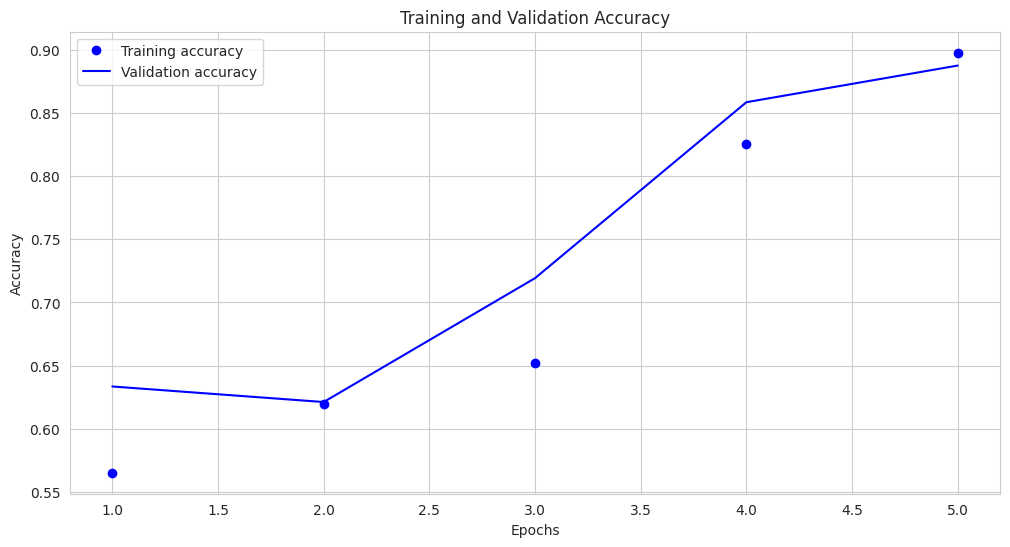

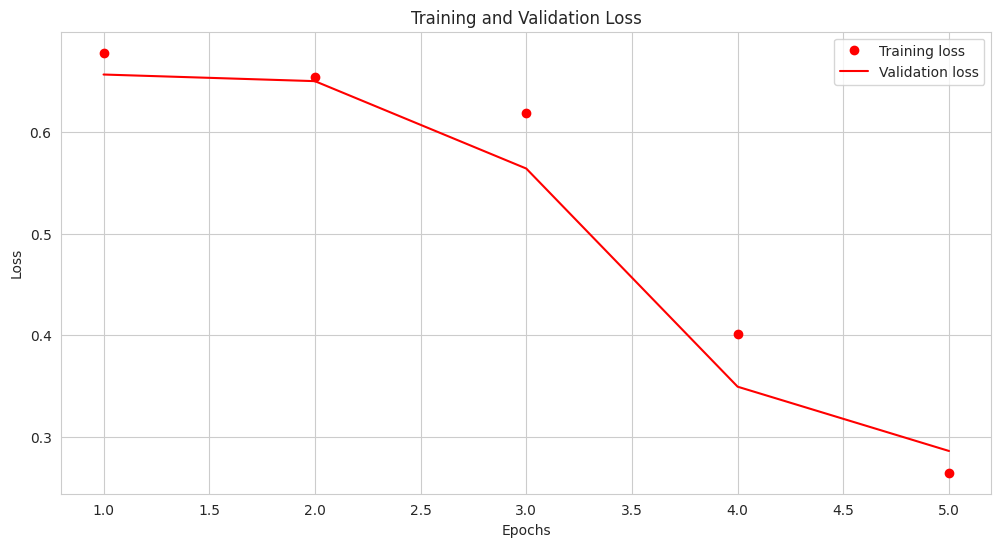

In [57]:
# We will use matplotlib to create our plots.
import matplotlib.pyplot as plt

# The 'history' object returned by model.fit() contains a dictionary
# holding the loss and accuracy values for both training and validation.
history_dict = history.history
print("Keys available in history object:", history_dict.keys())

# Let's extract the metrics from the history dictionary.
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# We need a range of numbers for the x-axis, which will represent the epochs.
# The number of epochs is simply the length of our accuracy/loss lists.
epochs = range(1, len(acc) + 1)

# --- Plot 1: Training and Validation Accuracy ---

# plt.figure() creates a new figure for plotting. figsize sets the width and height.
plt.figure(figsize=(12, 6))
# 'bo' creates a blue dot for each data point.
plt.plot(epochs, acc, 'bo', label='Training accuracy')
# 'b' creates a solid blue line.
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# plt.legend() displays the legend with the labels we provided.
plt.legend()
# plt.show() displays the plot.
plt.show()

# --- Plot 2: Training and Validation Loss ---

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [58]:
# The model.evaluate() method computes the loss and metrics for the given data.
# It's the standard way to get the final performance score on your test set.
# We pass it the padded test features and the final numerical test labels.
# The 'verbose=2' argument just makes the output a little cleaner.
final_loss, final_accuracy = model.evaluate(X_test_padded, y_test_final, verbose=2)

# Let's print the results in a nicely formatted way.
print(f"\\nFinal LSTM Model Performance on Test Data:")
print(f"Loss: {final_loss:.4f}")
print(f"Accuracy: {final_accuracy:.4f} ({(final_accuracy * 100):.2f}%)")

313/313 - 10s - 30ms/step - accuracy: 0.8874 - loss: 0.2861
\nFinal LSTM Model Performance on Test Data:
Loss: 0.2861
Accuracy: 0.8874 (88.74%)


In [59]:
# 1. Get the raw probability predictions from the model.
# The output will be a 2D array of shape (10000, 1).
y_pred_probs = model.predict(X_test_padded)

# 2. Convert probabilities to binary class labels (0 or 1).
# We use a simple list comprehension with a 0.5 threshold.
# The .flatten() method converts the (10000, 1) array into a 1D array of shape (10000,).
y_pred_lstm = [1 if prob > 0.5 else 0 for prob in y_pred_probs.flatten()]

# Now y_pred_lstm is a list of 0s and 1s, just like our y_test_final.
# We can now use the same Scikit-learn tools we used for our baseline!

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step


\n--- LSTM Model Classification Report ---
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

\n--- LSTM Model Confusion Matrix ---


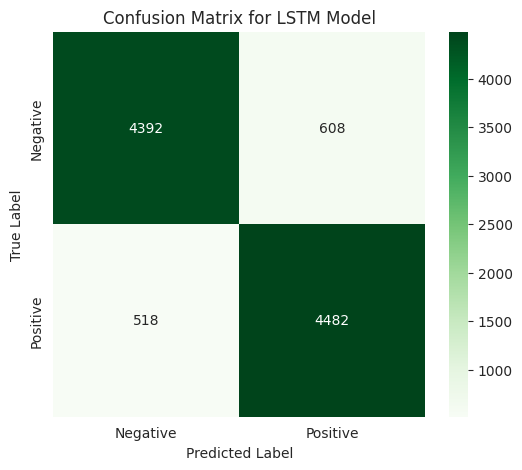

In [60]:
# We'll use the same functions we imported much earlier.
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# --- Classification Report ---
print("\\n--- LSTM Model Classification Report ---")
print(classification_report(y_test_final, y_pred_lstm, target_names=['Negative', 'Positive']))

# --- Confusion Matrix ---
print("\\n--- LSTM Model Confusion Matrix ---")
cm_lstm = confusion_matrix(y_test_final, y_pred_lstm)
class_names = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LSTM Model')
plt.show()

In [61]:
!pip install Flask

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 8.4 MB/s eta 0:00:00

[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
